In [20]:
import numpy as np
import pandas as pd
from scipy import stats
import random
from datetime import datetime, timedelta
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine



In [3]:
print(random.seed(42))

None


In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import random
from datetime import datetime, timedelta
from faker import Faker

# ── Reproductibilité ─────────────────────────────────────────────────────────
random.seed(42)
np.random.seed(42)
fake = Faker()
Faker.seed(42)

# ── Paramètres ──────────────────────────────────────────────────────────────
NB_USERS = 500
INTERESTS = ["fitness", "musique", "technologie", "cuisine", "voyage", "cinema"]

# Paramètres de concentration de la loi de Dirichlet
# Plus alpha est élevé → plus l'intérêt est fréquent
# fitness (3.0) plus répandu que cinema (0.5)
ALPHA = [3.0, 2.5, 2.0, 1.5, 1.0, 0.5]

# ── Génération des probabilités via Dirichlet ────────────────────────────────
INTEREST_PROBS = stats.dirichlet.rvs(alpha=ALPHA, random_state=42)[0]

ACTIONS = {
    "fitness":     ["watched workout video", "bought protein powder",
                    "liked gym post", "joined gym"],
    "musique":     ["watched music video", "bought headphones",
                    "liked song", "attended concert", "streamed album"],
    "technologie": ["watched AI talk", "read tech blog", "bought laptop",
                    "bought smartwatch", "liked AI article",
                    "contributed to open source"],
    "cuisine":     ["watched cooking show", "bought ingredients",
                    "liked recipe post", "tried new recipe",
                    "bought kitchen gadget"],
    "voyage":      ["watched travel vlog", "booked flight", "bought luggage",
                    "liked travel photo", "checked into hotel"],
    "cinema":      ["watched movie", "watched trailer", "bought streaming sub",
                    "rated film", "bought cinema ticket"],
}

# ── Inférence du type d'action ───────────────────────────────────────────────
def infer_action_type(action):
    """Déduit le type d'action à partir du verbe."""
    if isinstance(action, str):
        if action.startswith(("watched", "read", "streamed")):
            return "view"
        if action.startswith("bought") or action == "booked flight":
            return "buy"
        if action.startswith("liked") or action == "rated film":
            return "like"
    return "other"

# ── Génération des profils ────────────────────────────────
def generate_users(n=NB_USERS):
    profiles = []
    for i in range(n):
        age = int(np.clip(np.random.normal(loc=35, scale=10), 18, 65))
        nb_interests = random.randint(1, 6)
        interests = list(np.random.choice(
            INTERESTS, size=nb_interests, replace=False, p=INTEREST_PROBS
        ))

        # Pour chaque intérêt, l'utilisateur ne fait qu'un sous-ensemble
        # des actions disponibles (pas toutes !)
        user_actions = {}
        for interest in interests:
            available = ACTIONS[interest]
            k = random.randint(1, max(1, len(available) // 2))
            user_actions[interest] = random.sample(available, k=k)

        # Générer l'activity_log
        activity_log = []
        for _ in range(random.randint(5, 15)):
            # 80% du temps : activité dans ses intérêts
            # 20% du temps : activité hors intérêts
            if random.random() < 0.80:
                category = random.choice(interests)
            else:
                other = [c for c in INTERESTS if c not in interests]
                if other:
                    category = random.choice(other)
                else:
                    category = random.choice(interests)
  
            # Utiliser le sous-ensemble d'actions de cet utilisateur
            if category in user_actions:
                activity_log.append(random.choice(user_actions[category]))
            else:
                # Hors intérêts : on prend une action au hasard
                activity_log.append(random.choice(ACTIONS[category]))

        profiles.append({
            "name":         fake.name(),
            "age":          age,
            "interests":    interests,
            "activity_log": activity_log,
        })
    return profiles

# ── Conversion en DataFrames pour l'analyse ─────────────────────────────────
def profiles_to_dataframes(profiles):
    """Convertit les profils en 2 DataFrames : users + logs."""
    user_records = []
    log_records  = []
    base_date = datetime(2024, 1, 1)

    for idx, profile in enumerate(profiles):
        # DataFrame utilisateurs
        user_records.append({
            "user_id":   idx + 1,
            "name":      profile["name"],
            "age":       profile["age"],
            "interests": profile["interests"],
        })

        # DataFrame logs
        for action in profile["activity_log"]:
            action_type = infer_action_type(action)
            # Déduire la catégorie de l'action
            category = None
            for cat, actions in ACTIONS.items():
                if action in actions:
                    category = cat
                    break

            delta = timedelta(days=random.randint(0, 180),
                              hours=random.randint(0, 23))
            ts = base_date + delta
            log_records.append({
                "user_id":     idx + 1,
                "action":      action,
                "action_type": action_type,
                "category":    category,
                "timestamp":   ts,
                "hour":        ts.hour,
            })

    users_df = pd.DataFrame(user_records)
    logs_df  = pd.DataFrame(log_records)
    return users_df, logs_df

# ── Injection de bruit (doublons + NaN) ──────────────────────────────────────
def inject_noise(df, dup_fraction=0.03, nan_fraction=0.02):
    """Injecte des doublons et des NaN pour simuler des données réelles."""
    df_noisy = df.copy()

    # ── Doublons ──
    n_dup = int(len(df_noisy) * dup_fraction)
    dup_rows = df_noisy.sample(n=n_dup, random_state=42)
    df_noisy = pd.concat([df_noisy, dup_rows], ignore_index=True)

    # ── Valeurs manquantes ──
    n_nan = int(len(df_noisy) * nan_fraction)
    nan_indices = df_noisy.sample(n=n_nan, random_state=42).index
    for idx in nan_indices:
        col = random.choice(["action", "category", "hour"])
        df_noisy.loc[idx, col] = np.nan

    return df_noisy
def clean_data(users_df, logs_df):
    logs_df = logs_df.drop_duplicates()
    logs_df = logs_df.dropna(subset=["action", "category"])
    users_df["age_normalized"] = (users_df["age"] - users_df["age"].mean()) / users_df["age"].std()
    return users_df, logs_df
# ── Exécution ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # 1. Générer les probabilités d'intérêts via Dirichlet
    print("=== Probabilités d'intérêts (Dirichlet) ===")
    for interest, prob in zip(INTERESTS, INTEREST_PROBS):
        print(f"  {interest}: {prob:.4f}")

    # 2. Générer les profils (format dict comme le sujet)
    profiles = generate_users()

    # 3. Afficher un profil exemple
    print("\n=== Exemple de profil ===")
    print(profiles[0])

    # 4. Convertir en DataFrames pour l'analyse
    users_df, logs_df = profiles_to_dataframes(profiles)
    logs_df = inject_noise(logs_df)

    print("\n=== DataFrame Utilisateurs ===")
    print(users_df.head())
    print(f"\nShape : {users_df.shape}")

    print("\n=== DataFrame Logs ===")
    print(logs_df.head())
    print(f"\nShape : {logs_df.shape}")
    print(f"Valeurs manquantes :\n{logs_df.isnull().sum()}")
    print(f"Doublons : {logs_df.duplicated().sum()}")

=== Probabilités d'intérêts (Dirichlet) ===
  fitness: 0.2874
  musique: 0.1589
  technologie: 0.1115
  cuisine: 0.0752
  voyage: 0.0741
  cinema: 0.2928

=== Exemple de profil ===
{'name': 'Allison Hill', 'age': 39, 'interests': [np.str_('cinema'), np.str_('cuisine'), np.str_('fitness'), np.str_('technologie'), np.str_('musique'), np.str_('voyage')], 'activity_log': ['watched movie', 'booked flight', 'streamed album', 'watched movie', 'watched workout video', 'watched workout video', 'watched movie', 'streamed album']}

=== DataFrame Utilisateurs ===
   user_id             name  age  \
0        1     Allison Hill   39   
1        2      Noah Rhodes   33   
2        3  Angie Henderson   29   
3        4    Daniel Wagner   29   
4        5  Cristian Santos   28   

                                           interests  
0  [cinema, cuisine, fitness, technologie, musiqu...  
1                                           [cinema]  
2                    [fitness, musique, technologie]  
3    

In [19]:


# ── Catalogue de contenu ─────────────────────────────────────────────────────
CONTENT_CATALOG = {
    "fitness": [
        "Programme HIIT 30 min",
        "Yoga débutant — 7 jours",
        "Plan nutrition semaine",
        "Top 10 exercices cardio",
        "Guide musculation maison",
    ],
    "musique": [
        "Playlist Rock 2024",
        "Top Jazz lo-fi",
        "Concerts à venir près de chez vous",
        "Histoire du Hip-Hop",
        "Playlist focus & productivité",
    ],
    "technologie": [
        "Blog IA du MIT",
        "Podcast No Code",
        "Cours Python avancé",
        "Les dernières avancées en LLM",
        "Guide débutant open source",
    ],
    "cuisine": [
        "Recettes végétariennes rapides",
        "Cours pâtisserie en ligne",
        "Top ustensiles 2024",
        "Cuisine du monde en 30 min",
        "Meal prep de la semaine",
    ],
    "voyage": [
        "Top destinations 2024",
        "Guide voyage solo",
        "Astuces bagages cabine",
        "Applications voyage indispensables",
        "Road trips Europe",
    ],
    "cinema": [
        "Top films Netflix ce mois",
        "Les classiques à voir absolument",
        "Documentaires tendance",
        "Podcast analyse cinéma",
        "Films primés aux Oscars 2024",
    ],
}

# ── Classe principale ────────────────────────────────────────────────────────
class RecommendationEngine:

    def __init__(self, users_df, logs_df, catalog=CONTENT_CATALOG):
        self.users_df = users_df
        self.logs_df  = logs_df
        self.catalog  = catalog

    # ── ① Associer intérêts → contenu ───────────────────────────────────────
    def match_interests(self, interests):
        """
        Retourne le contenu disponible pour chaque intérêt de l'utilisateur.
        """
        matched = {}
        for interest in interests:
            if interest in self.catalog:
                matched[interest] = self.catalog[interest]
        return matched

    # ── ② Générer des recommandations personnalisées ─────────────────────────
    def recommend_from_similar(self, user_id, n=3):
        """
        Génère des recommandations basées sur les comportements
        des utilisateurs similaires.
        """
        user = self.users_df[self.users_df["user_id"] == user_id]
        if user.empty:
            return []
    
        # 1. Trouver les utilisateurs similaires
        similar_users = self.find_similar(user_id, top_k=5)
        if not similar_users:
            return []
    
        # 2. Collecter les actions des utilisateurs similaires
        similar_ids = [uid for uid, _, _ in similar_users]
        similar_logs = self.logs_df[
            self.logs_df["user_id"].isin(similar_ids)
        ]
    
        # 3. Identifier les catégories les plus populaires
        #    parmi ces utilisateurs similaires
        popular_categories = (
            similar_logs["category"]
            .dropna()
            .value_counts()
            .head(3)
            .index.tolist()
        )
    
        # 4. Exclure les catégories que l'utilisateur connaît déjà
        user_interests = user.iloc[0]["interests"]
        new_categories = [
            c for c in popular_categories 
            if c not in user_interests
        ]
    
        # 5. Générer des suggestions depuis ces nouvelles catégories
        recommendations = []
        for category in new_categories:
            if category not in self.catalog:
                continue
            items = np.random.choice(
                self.catalog[category],
                size=min(n, len(self.catalog[category])),
                replace=False
            ).tolist()
            recommendations.append({
                "category": category,
                "recommendations": items,
                "reason": f"Les utilisateurs avec un profil similaire "
                          f"au vôtre apprécient '{category}'"
            })
    
        return recommendations
    
    def recommend(self, user_id, n=3):
        """
        Génère n recommandations pour un utilisateur donné.
        Logique :
          - Priorité aux intérêts avec le plus d'activité dans les logs
          - Suggestions adaptées dynamiquement selon le type d'action dominant
        """
        user = self.users_df[self.users_df["user_id"] == user_id]
        if user.empty:
            return f"Utilisateur {user_id} introuvable."

        interests = user.iloc[0]["interests"]
        user_logs = self.logs_df[self.logs_df["user_id"] == user_id]

        # Compter les activités par catégorie → prioriser les plus actives
        if not user_logs.empty and "category" in user_logs.columns:
            category_counts = (
                user_logs["category"]
                .dropna()
                .value_counts()
            )
            # Trier les intérêts par activité décroissante
            sorted_interests = sorted(
                interests,
                key=lambda x: category_counts.get(x, 0),
                reverse=True
            )
        else:
            sorted_interests = interests

        # Détecter le type d'action dominant (view / buy / like)
        dominant_type = "view"  # défaut
        if not user_logs.empty and "action_type" in user_logs.columns:
            type_counts = user_logs["action_type"].dropna().value_counts()
            if not type_counts.empty:
                dominant_type = type_counts.idxmax()

        # Construire les recommandations
        recommendations = []
        for interest in sorted_interests:
            if interest not in self.catalog:
                continue
            items = self.catalog[interest].copy()

            # Logique conditionnelle selon le type dominant
            if dominant_type == "buy":
                # Acheteur → mettre en avant les guides et cours
                items = [i for i in items if any(
                    w in i.lower() for w in ["guide", "cours", "plan", "top"]
                )] or items

            elif dominant_type == "like":
                # Likeur → mettre en avant les tendances
                items = [i for i in items if any(
                    w in i.lower() for w in ["top", "tendance", "2024"]
                )] or items

            # Prendre n items au hasard dans la catégorie
            picked = np.random.choice(items, size=min(n, len(items)),
                                      replace=False).tolist()
            recommendations.append({
                "interest":        interest,
                "recommendations": picked,
                "reason": f"Basé sur votre intérêt pour '{interest}' "
                          f"(activité dominante : {dominant_type})"
            })

        return recommendations

    # ── ③ Trouver des utilisateurs similaires (cosinus) ── FACULTATIF ────────
    def build_vector(self, uid, interests):
            """
            Vecteur basé sur les actions individuelles, pas les catégories.
            Beaucoup plus discriminant car il y a ~30 actions possibles.
            """
            # Lister toutes les actions possibles dans le catalogue
            all_actions = [
                action 
                for actions in ACTIONS.values() 
                for action in actions
            ]  # → ~30 actions uniques
        
            user_logs = self.logs_df[self.logs_df["user_id"] == uid]
            counts = user_logs["action"].dropna().value_counts()
            total = counts.sum() if counts.sum() > 0 else 1
        
            # Fréquence de chaque action spécifique
            action_vec = np.array(
                [counts.get(a, 0) / total for a in all_actions]
            )
        
            # Intérêts binaires gardés pour le contexte
            interest_vec = np.array(
                [1.0 if i in interests else 0.0 
                 for i in list(CONTENT_CATALOG.keys())]
            )
        
            return np.concatenate([interest_vec, action_vec])

        
    def find_similar(self, user_id, top_k=3):
        """
        Similarité cosinus sur un vecteur enrichi :
        [intérêt binaire × 6] + [fréquence d'activité par catégorie × 6]
        """
        all_interests = list(self.catalog.keys())

        user = self.users_df[self.users_df["user_id"] == user_id]
        if user.empty:
            return []
    
        target_vec = self.build_vector(user_id, user.iloc[0]["interests"])
    
        similarities = []
        for _, row in self.users_df.iterrows():
            if row["user_id"] == user_id:
                continue
            vec = self.build_vector(row["user_id"], row["interests"])
            if np.any(target_vec) and np.any(vec):
                sim = 1 - cosine(target_vec, vec)
            else:
                sim = 0.0
            similarities.append((row["user_id"], row["name"], sim))
    
        similarities.sort(key=lambda x: x[2], reverse=True)
        return similarities[:top_k]
    

    # ── Affichage formaté ────────────────────────────────────────────────────
    def display_recommendations(self, user_id):
        recs = self.recommend(user_id)
        user = self.users_df[self.users_df["user_id"] == user_id].iloc[0]
        print(f"\n{'='*55}")
        print(f"  Recommandations pour {user['name']} (âge {user['age']})")
        print(f"  Intérêts : {', '.join(user['interests'])}")
        print(f"{'='*55}")
        for block in recs:
            print(f"\n  [{block['interest'].upper()}]")
            for item in block["recommendations"]:
                print(f"    • {item}")
            print(f"    → {block['reason']}")

        # Utilisateurs similaires
        similar = self.find_similar(user_id)
        if similar:
            print(f"\n  Utilisateurs avec des goûts similaires :")
            for uid, name, score in similar:
                print(f"    • {name} (similarité : {score:.2f})")
        print(f"{'='*55}\n")

        collab = self.recommend_from_similar(user_id)
        if collab:
            print("\n  Découvertes basées sur des profils similaires :")
            for block in collab:
                print(f"\n  [{block['category'].upper()}]")
                for item in block["recommendations"]:
                    print(f"    • {item}")
                print(f"    → {block['reason']}")


# ── Exécution ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # from data_generator import generate_users, profiles_to_dataframes, inject_noise

    profiles = generate_users()
    users_df, logs_df = profiles_to_dataframes(profiles)
    logs_df = inject_noise(logs_df)

    engine = RecommendationEngine(users_df, logs_df)

    # Tester sur 3 utilisateurs
    for uid in [1, 2, 3]:
        engine.display_recommendations(uid)


  Recommandations pour Richard Harper (âge 26)
  Intérêts : cinema

  [CINEMA]
    • Top films Netflix ce mois
    • Documentaires tendance
    • Les classiques à voir absolument
    → Basé sur votre intérêt pour 'cinema' (activité dominante : view)

  Utilisateurs avec des goûts similaires :
    • Jonathan Sanchez (similarité : 1.00)
    • Caleb Ponce (similarité : 1.00)
    • Randall Cox (similarité : 0.97)


  Découvertes basées sur des profils similaires :

  [VOYAGE]
    • Top destinations 2024
    • Astuces bagages cabine
    • Guide voyage solo
    → Les utilisateurs avec un profil similaire au vôtre apprécient 'voyage'

  [FITNESS]
    • Yoga débutant — 7 jours
    • Plan nutrition semaine
    • Programme HIIT 30 min
    → Les utilisateurs avec un profil similaire au vôtre apprécient 'fitness'

  Recommandations pour Michael Jensen (âge 34)
  Intérêts : technologie, voyage

  [TECHNOLOGIE]
    • Cours Python avancé
    • Guide débutant open source
    → Basé sur votre intérêt 

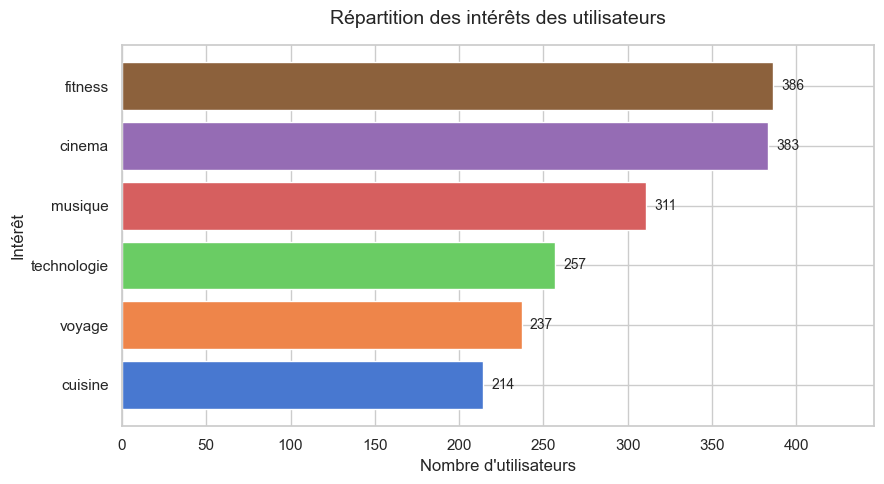

✅ Viz 1 sauvegardée


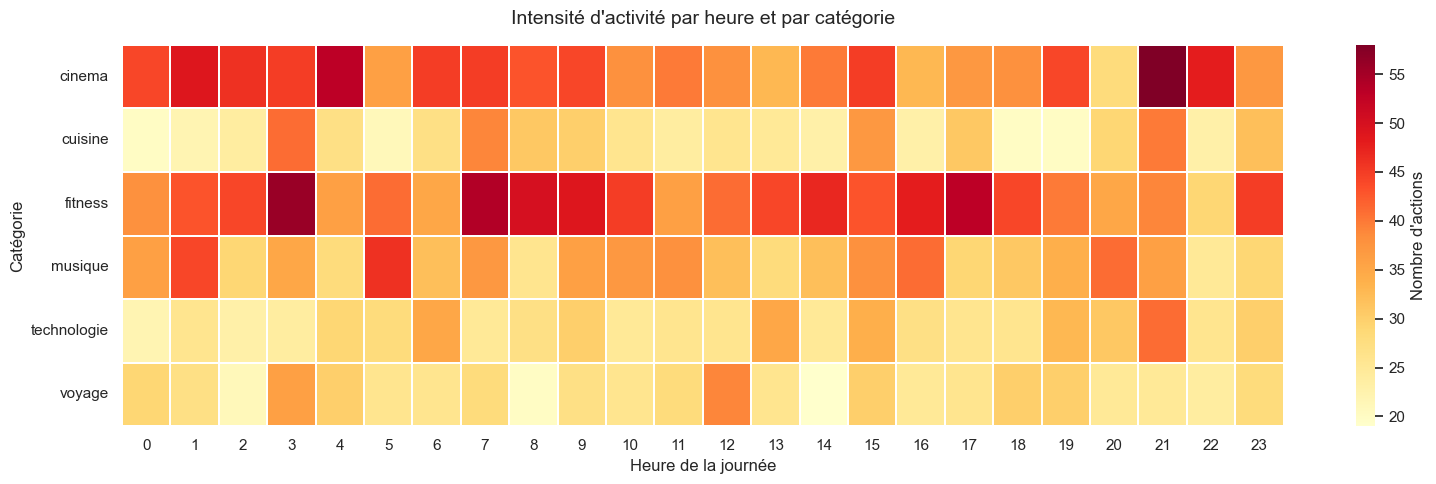

✅ Viz 2 sauvegardée


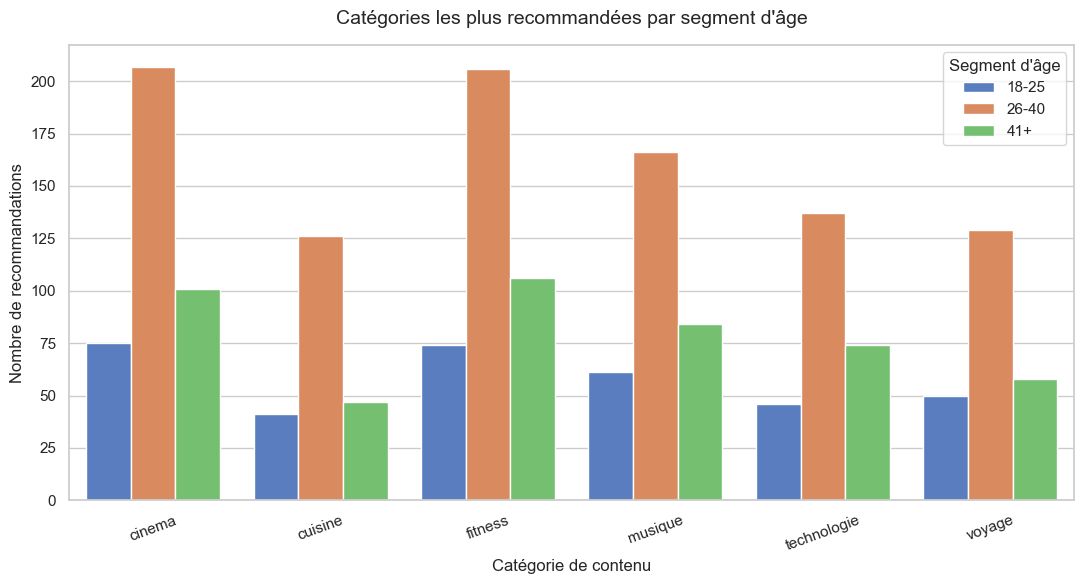

✅ Viz 3 sauvegardée


In [21]:

# ── Style global ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")

# ─────────────────────────────────────────────────────────────────────────────
# VIZ 1 — Répartition des intérêts des utilisateurs
# ─────────────────────────────────────────────────────────────────────────────
def plot_interest_distribution(users_df):
    """
    Barplot horizontal de la fréquence de chaque intérêt
    parmi tous les utilisateurs.
    """
    # Exploser la colonne interests (une ligne par intérêt)
    interests_exploded = users_df["interests"].explode()
    counts = interests_exploded.value_counts().sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(counts.index, counts.values,
                   color=sns.color_palette("muted", len(counts)))

    # Valeurs sur les barres
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=10)

    ax.set_title("Répartition des intérêts des utilisateurs", fontsize=14, pad=15)
    ax.set_xlabel("Nombre d'utilisateurs")
    ax.set_ylabel("Intérêt")
    ax.set_xlim(0, counts.max() + 60)
    plt.tight_layout()
    plt.savefig("outputs/viz1_interest_distribution.png", dpi=150)
    plt.show()
    print("✅ Viz 1 sauvegardée")


# ─────────────────────────────────────────────────────────────────────────────
# VIZ 2 — Heatmap intensité d'activité par heure × catégorie
# ─────────────────────────────────────────────────────────────────────────────
def plot_activity_heatmap(logs_df):
    """
    Heatmap : lignes = catégories, colonnes = tranches horaires (0-23h)
    Intensité = nombre d'actions par case.
    """
    logs_clean = logs_df.dropna(subset=["category", "hour"])
    logs_clean = logs_clean.copy()
    logs_clean["hour"] = logs_clean["hour"].astype(int)

    # Tableau croisé catégorie × heure
    pivot = logs_clean.pivot_table(
        index="category",
        columns="hour",
        values="action",
        aggfunc="count",
        fill_value=0
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="white",
        annot=False,
        cbar_kws={"label": "Nombre d'actions"}
    )

    ax.set_title("Intensité d'activité par heure et par catégorie", fontsize=14, pad=15)
    ax.set_xlabel("Heure de la journée")
    ax.set_ylabel("Catégorie")
    plt.tight_layout()
    plt.savefig("outputs/viz2_activity_heatmap.png", dpi=150)
    plt.show()
    print("✅ Viz 2 sauvegardée")


# ─────────────────────────────────────────────────────────────────────────────
# VIZ 3 — Catégories les plus recommandées par segment d'utilisateurs
# ─────────────────────────────────────────────────────────────────────────────
def plot_recommendations_by_segment(users_df, engine):
    """
    Barplot groupé : pour chaque segment d'âge,
    quelles catégories sont le plus recommandées ?
    """
    # Ajouter age_group si absent
    if "age_group" not in users_df.columns:
        users_df = users_df.copy()
        users_df["age_group"] = users_df["age"].apply(
            lambda a: "18-25" if a < 26 else "26-40" if a < 41 else "41+"
        )
        engine.users_df = users_df

    # Faire tourner le moteur sur tous les utilisateurs
    records = []
    for _, user in users_df.iterrows():
        recs = engine.recommend(user["user_id"])
        for block in recs:
            records.append({
                "age_group": user["age_group"],
                "category":  block["interest"]
            })

    recs_df = pd.DataFrame(records)

    # Compter par segment × catégorie
    counts = (
        recs_df.groupby(["age_group", "category"])
        .size()
        .reset_index(name="count")
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(
        data=counts,
        x="category",
        y="count",
        hue="age_group",
        palette="muted",
        ax=ax
    )

    ax.set_title("Catégories les plus recommandées par segment d'âge",
                 fontsize=14, pad=15)
    ax.set_xlabel("Catégorie de contenu")
    ax.set_ylabel("Nombre de recommandations")
    ax.legend(title="Segment d'âge")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("outputs/viz3_recommendations_by_segment.png", dpi=150)
    plt.show()
    print("✅ Viz 3 sauvegardée")


# ─────────────────────────────────────────────────────────────────────────────
# Exécution
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import os
    os.makedirs("outputs", exist_ok=True)

    # Réutiliser les données déjà générées
    profiles = generate_users()
    users_df, logs_df = profiles_to_dataframes(profiles)
    logs_df = inject_noise(logs_df)
    users_df, logs_df = clean_data(users_df, logs_df)

    engine = RecommendationEngine(users_df, logs_df)

    plot_interest_distribution(users_df)
    plot_activity_heatmap(logs_df)
    plot_recommendations_by_segment(users_df, engine)